<a href="https://colab.research.google.com/github/paolapeiz/Practicas/blob/main/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import time

# Verificar GPU
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU disponible: {gpus[0].name}")
else:
    print("❌ GPU no disponible. Actívala en Entorno de ejecución -> Cambiar tipo de entorno de ejecución -> T4 GPU")

TensorFlow version: 2.19.0
✅ GPU disponible: /physical_device:GPU:0


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("x_train shape:", x_train.shape)   # (50000, 32, 32, 3)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)

class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Hiperparámetros clave
IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)


In [ ]:
def preprocess_images(images, labels):
    images = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    images = preprocess_input(images)   # Escala específica de EfficientNet ([-1,1] aprox)
    labels = tf.one_hot(labels, depth=10)
    labels = tf.reshape(labels, (-1, 10))
    return images, labels

# División train/val 80/20
full_train = tf.data.Dataset.from_tensor_slices((x_train, y_train))
full_train = full_train.shuffle(50000, seed=42)

train_size = int(0.8 * len(x_train))
train_ds = full_train.take(train_size)
val_ds = full_train.skip(train_size)

# Aplicar batching, map y prefetch
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(preprocess_images, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.map(preprocess_images, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.map(preprocess_images, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Verificación
for img, lbl in train_ds.take(1):
    print("Rango de imágenes (debe estar cerca de [-1,1]):", img.numpy().min(), img.numpy().max())
    print("Forma etiquetas:", lbl.numpy().shape)

Rango de imágenes (debe estar cerca de [-1,1]): 0.0 255.0
Forma etiquetas: (32, 10)


In [ ]:
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Data augmentation suave (evita sobreajuste)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])

# Cabezal clasificador
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)   # Más capacidad
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,712,621 (17.98 MB)

 Trainable params: 662,026 (2.53 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

In [ ]:
# Calculamos steps por época para cubrir todo el dataset
steps_per_epoch = train_ds.cardinality().numpy()  # Número de batches en train
validation_steps = val_ds.cardinality().numpy()   # Número de batches en val

print(f"Steps por época: {steps_per_epoch}, validation steps: {validation_steps}")

callbacks_fase1 = [
    keras.callbacks.ModelCheckpoint("modelo_fase1.keras", save_best_only=True, monitor='val_accuracy'),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("🚀 Fase 1: Entrenando cabeza...")
start_time = time.time()
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,                     # Suficientes, early stopping parará antes
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_fase1
)
print(f"Tiempo fase 1: {(time.time()-start_time)/60:.2f} minutos")

# Evaluación rápida en test
test_loss, test_acc = model.evaluate(test_ds)
print(f"📊 Accuracy tras fase 1: {test_acc:.4f}")

Steps por época: 1250, validation steps: 313
🚀 Fase 1: Entrenando cabeza...
Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 43ms/step - accuracy: 0.7966 - loss: 0.6460 - val_accuracy: 0.9007 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.8392 - loss: 0.4813 - val_accuracy: 0.9056 - val_loss: 0.2713 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 40ms/step - accuracy: 0.8512 - loss: 0.4409 - val_accuracy: 0.9117 - val_loss: 0.2620 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.8524 - loss: 0.4302 - val_accuracy: 0.9140 - val_loss: 0.2493 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.8589 - loss: 0.4142 - val_accuracy: 0.9180 - val_loss: 0.2355 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.8638 - loss: 0.4014 - val_accuracy: 0.9203 - val_loss: 0.2200 - learning_r

In [ ]:
# Descongelar solo las últimas 40 capas de EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

print(f"Capas entrenables en fine-tuning: {sum(1 for l in base_model.layers if l.trainable)}")

# Recompilar con learning rate muy bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    keras.callbacks.ModelCheckpoint("modelo_finetune.keras", save_best_only=True, monitor='val_accuracy'),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
]

print("🔥 Fase 2: Fine-tuning...")
start_time = time.time()
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_fase2
)
print(f"Tiempo fase 2: {(time.time()-start_time)/60:.2f} minutos")

Capas entrenables en fine-tuning: 40
🔥 Fase 2: Fine-tuning...
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.8163 - loss: 0.6125 - val_accuracy: 0.9230 - val_loss: 0.2263
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.8503 - loss: 0.4729 - val_accuracy: 0.9340 - val_loss: 0.1869
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 50ms/step - accuracy: 0.8658 - loss: 0.4217 - val_accuracy: 0.9427 - val_loss: 0.1561
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.8755 - loss: 0.3882 - val_accuracy: 0.9492 - val_loss: 0.1424
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.8803 - loss: 0.3634 - val_accuracy: 0.9525 - val_loss: 0.1322
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.8870 - loss: 0.3415 - val_accuracy: 0.9561 - val_loss: 0.1276
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.8936 - loss: 0.3165 - val_accuracy: 0.9608 - val_loss: 0.1168
Epoch 8/20
125

In [ ]:
# Cargar el mejor modelo de fine-tuning
best_model = keras.models.load_model("modelo_finetune.keras")

# Evaluar en todo el test set
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\n🎯 PRECISIÓN FINAL EN TEST: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9268 - loss: 0.2226

🎯 PRECISIÓN FINAL EN TEST: 0.9268


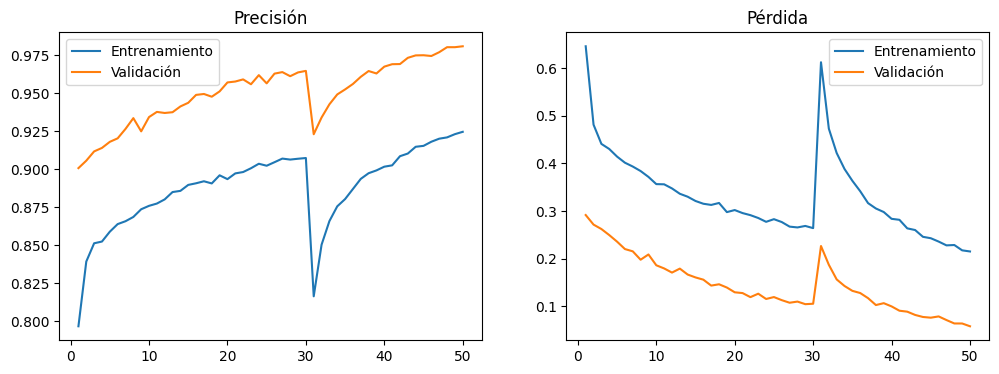

In [ ]:
# Concatenar historiales
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Entrenamiento')
plt.plot(epochs_range, val_acc, label='Validación')
plt.legend()
plt.title('Precisión')
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Entrenamiento')
plt.plot(epochs_range, val_loss, label='Validación')
plt.legend()
plt.title('Pérdida')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


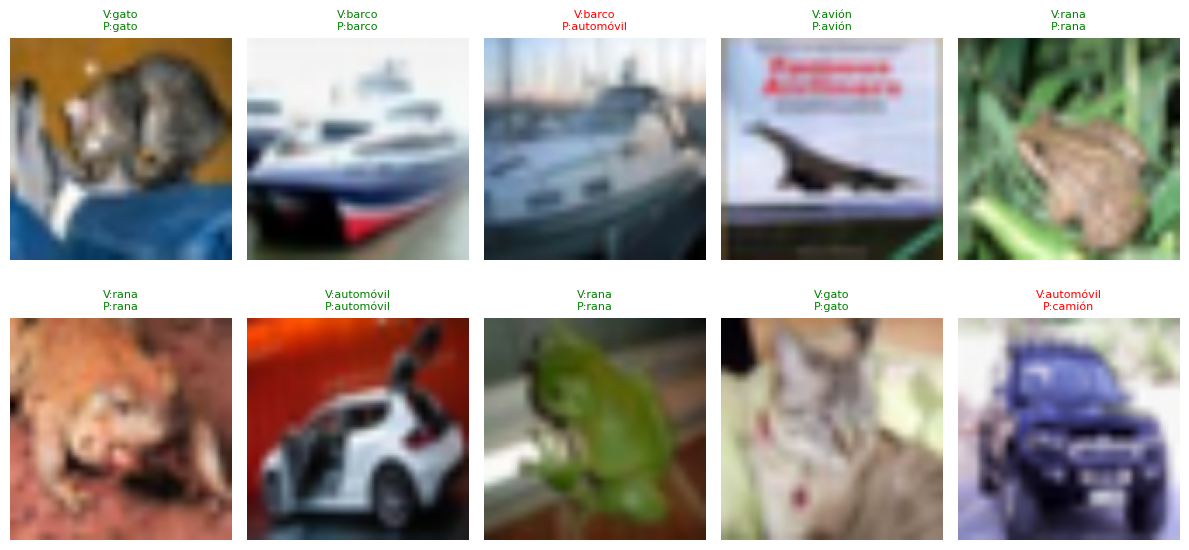

In [ ]:
from tensorflow.keras.preprocessing.image import array_to_img

for images, labels in test_ds.take(1):
    preds = best_model.predict(images)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    plt.figure(figsize=(12,6))
    for i in range(10):
        plt.subplot(2,5,i+1)
        img = array_to_img(images[i])
        plt.imshow(img)
        true_label = class_names[true_classes[i]]
        pred_label = class_names[pred_classes[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"V:{true_label}\nP:{pred_label}", color=color, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()